<a href="https://colab.research.google.com/github/Keistkmiya/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter_01_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Introduction
Pada bab ini, kita akan mempelajari konsep dasar Machine Learning melalui studi kasus klasifikasi bunga Iris.

### Library Utama:
- **scikit-learn**: Berisi algoritma machine learning yang akan kita gunakan.
- **NumPy & Pandas**: Untuk pengolahan data angka dan tabel.
- **Matplotlib**: Untuk visualisasi data.

In [23]:
import sys
import pandas as pd
import matplotlib
import numpy as np
import scipy as sp
import IPython
import sklearn

print(f"Versi scikit-learn: {sklearn.__version__}")

Versi scikit-learn: 1.6.1


### 1.1 Meet the Data
Kita akan menggunakan dataset Iris yang berisi data pengukuran mahkota (sepal) dan kelopak (petal) bunga Iris. Tujuan kita adalah mengklasifikasikan spesies bunga berdasarkan ukuran tersebut.

In [24]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

print("Kunci dalam iris_dataset:", iris_dataset.keys())
print("Target names (Spesies):", iris_dataset['target_names'])
print("Feature names (Fitur):", iris_dataset['feature_names'])

Kunci dalam iris_dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Target names (Spesies): ['setosa' 'versicolor' 'virginica']
Feature names (Fitur): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 1.2 Training and Testing Data
Dalam Machine Learning, kita tidak boleh menguji model menggunakan data yang sama dengan data saat kita melatihnya. Mengapa? Karena model bisa saja hanya "menghafal" data tersebut (overfitting).

Kita akan membagi data menggunakan fungsi `train_test_split`:
- **Training Data**: 75% dari total data (digunakan untuk melatih model).
- **Testing Data**: 25% dari total data (digunakan untuk mengukur akurasi model).

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (112, 4)
Bentuk y_train: (112,)
Bentuk X_test: (38, 4)
Bentuk y_test: (38,)


### 1.3 Building Your First Model: k-Nearest Neighbors
Kita akan menggunakan algoritma k-NN dengan `n_neighbors=1`. Artinya, model akan memprediksi spesies bunga baru berdasarkan 1 tetangga yang paling mirip di dalam data training.

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

# Melatih model dengan data training
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### 1.4 Evaluating the Model
Kita akan menggunakan data testing (`X_test`) untuk melihat apakah model bisa menebak dengan benar. Hasilnya disebut sebagai **Accuracy Score**.

In [27]:
y_pred = knn.predict(X_test)
print(f"Hasil Prediksi: \n{y_pred}")

# Menghitung akurasi
print(f"Akurasi model: {knn.score(X_test, y_test):.2f}")

Hasil Prediksi: 
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Akurasi model: 0.97


# Chapter 2: Supervised Learning
Supervised Learning adalah tipe Machine Learning di mana kita memberikan model data beserta jawabannya (label). Tujuannya adalah agar model bisa belajar memetakan input ke output yang benar.

### Dua Tipe Utama:
1. **Classification (Klasifikasi)**: Memprediksi kategori (misal: spam atau bukan spam).
2. **Regression (Regresi)**: Memprediksi angka kontinu (misal: harga rumah atau suhu).

### Konsep Penting:
- **Generalization**: Kemampuan model memprediksi data baru yang belum pernah dilihat.
- **Overfitting**: Model terlalu hafal data latihan sehingga gagal memprediksi data baru.
- **Underfitting**: Model terlalu simpel sehingga tidak paham pola data.

In [28]:
!pip install mglearn

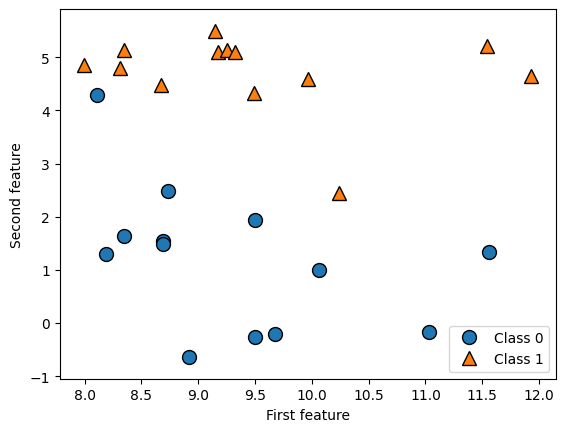

Bentuk data X: (26, 2)


In [29]:
import mglearn
import matplotlib.pyplot as plt
import numpy as np

# Membuat dataset buatan (Forge Dataset untuk Klasifikasi)
X, y = mglearn.tools.make_handcrafted_dataset()

# Visualisasi data
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

print(f"Bentuk data X: {X.shape}")

### 2.1 k-Nearest Neighbors Regression
Selain untuk klasifikasi, k-NN juga bisa digunakan untuk regresi. Di sini, kita mencoba memprediksi nilai numerik kontinu.

**Cara Kerja:**
- Untuk `n_neighbors=1`, prediksi adalah nilai dari tetangga terdekat.
- Untuk `n_neighbors > 1`, prediksi adalah rata-rata (mean) dari nilai tetangga-tetangga terdekatnya.

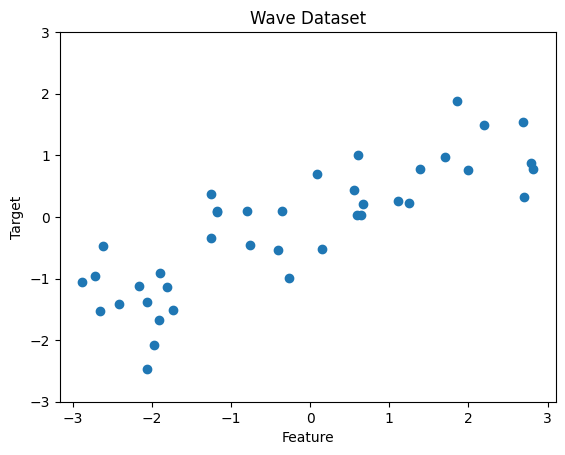

In [30]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Mengambil dataset wave buatan
X, y = mglearn.datasets.make_wave(n_samples=40)

# Membagi menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Visualisasi data awal
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Wave Dataset")
plt.show()

In [31]:
from sklearn.neighbors import KNeighborsRegressor

# Membuat instansiasi model
reg = KNeighborsRegressor(n_neighbors=3)

# Melatih model dengan data training
reg.fit(X_train, y_train)

# Melakukan prediksi pada data testing
print(f"Prediksi data testing:\n{reg.predict(X_test)}")

Prediksi data testing:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [32]:
print(f"Test set R^2: {reg.score(X_test, y_test):.2f}")

Test set R^2: 0.83


### 2.2 Analyzing KNeighborsRegressor
Untuk memahami pengaruh jumlah tetangga terhadap model, kita akan membandingkan prediksi menggunakan 1, 3, dan 9 tetangga.

**Teori Penting:**
- **n_neighbors = 1**: Model sangat mengikuti data training secara detail. Garis prediksi akan terlihat sangat tajam dan tidak beraturan. Ini berisiko menyebabkan **Overfitting**.
- **n_neighbors = banyak (misal 9)**: Prediksi menjadi lebih halus (smooth) karena merupakan rata-rata dari banyak tetangga. Namun, model bisa menjadi terlalu simpel dan kehilangan detail penting, yang disebut **Underfitting**.

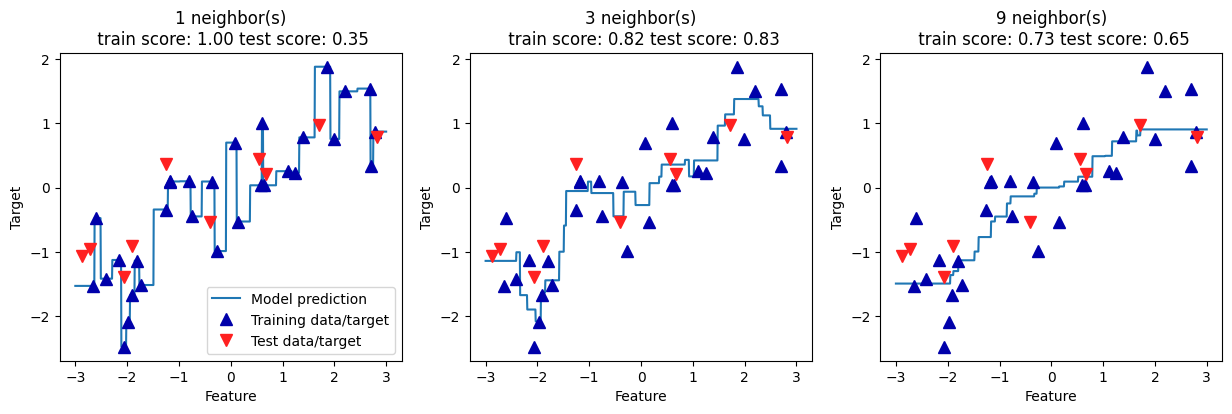

In [33]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Membuat 1000 titik data untuk prediksi (garis halus)
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes):
    # Membuat model dan melatihnya
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)

    # Melakukan prediksi
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        f"{n_neighbors} neighbor(s)\n train score: {reg.score(X_train, y_train):.2f} "
        f"test score: {reg.score(X_test, y_test):.2f}")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

axes[0].legend(["Model prediction", "Training data/target", "Test data/target"], loc="best")

**Kesimpulan dari Grafik:**
1. Pada **1 neighbor**, skor training sangat sempurna (1.00), tapi garis predisinya sangat bergejolak. Ini adalah tanda model terlalu sensitif terhadap noise pada data.
2. Seiring bertambahnya **neighbors**, garis prediksi menjadi lebih stabil dan halus.
3. Skor terbaik biasanya ditemukan pada titik tengah yang seimbang, di mana model tidak terlalu kompleks tapi juga tidak terlalu sederhana.

## 2.3 Linear Models
Linear Models adalah kelompok algoritma yang membuat prediksi menggunakan fungsi linear dari fitur-fitur inputnya. Untuk regresi, prediksi dilakukan dengan mencari garis lurus (atau bidang pada dimensi tinggi) yang paling mendekati data.

Persamaan matematis untuk model linear adalah:
$$y = w[0] \cdot x[0] + w[1] \cdot x[1] + ... + w[p] \cdot x[p] + b$$

**Keterangan:**
- $x[0]$ hingga $x[p]$ adalah fitur-fitur dari satu titik data.
- $w$ (weights) dan $b$ (bias) adalah parameter model yang dipelajari.
- $y$ adalah prediksi yang dihasilkan.

w[0]: 0.393906  b: -0.031804


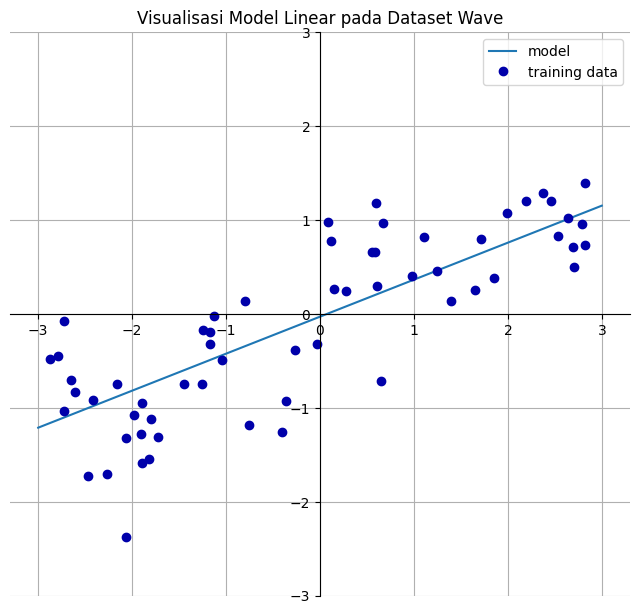

In [34]:
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_linear_regression_wave()
plt.title("Visualisasi Model Linear pada Dataset Wave")
plt.show()

## 2.4 Linear Regression (Ordinary Least Squares)
Linear Regression atau *Ordinary Least Squares* (OLS) adalah metode linear paling sederhana untuk regresi.

**Teori Singkat:**
Model ini mencari nilai parameter $w$ dan $b$ yang meminimalkan **Mean Squared Error (MSE)**, yaitu rata-rata kuadrat selisih antara nilai prediksi dengan nilai target yang sebenarnya pada data training. OLS tidak memiliki parameter tambahan (*hyperparameters*) untuk mengontrol kompleksitas model.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn

# Menyiapkan data
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Membangun model OLS
lr = LinearRegression().fit(X_train, y_train)

# Menampilkan parameter yang dipelajari
print(f"lr.coef_ (bobot/w): {lr.coef_}")
print(f"lr.intercept_ (bias/b): {lr.intercept_}")

lr.coef_ (bobot/w): [0.39390555]
lr.intercept_ (bias/b): -0.031804343026759746


## 2.5 Evaluating Linear Regression Performance
Setelah melatih model, kita perlu mengevaluasi seberapa baik model tersebut bekerja pada data yang sudah dilihat (training) dan data baru (testing).

**Kriteria Evaluasi:**
- Kita menggunakan skor $R^2$ (Koefisien Determinasi) yang berkisar antara 0 hingga 1.
- Jika skor training dan testing sama-sama rendah, itu tandanya model mengalami **Underfitting**.

In [36]:
print(f"Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Test set score: {lr.score(X_test, y_test):.2f}")

Training set score: 0.67
Test set score: 0.66


**Hasil Analisis:**
Pada dataset 'wave', kita mendapatkan skor sekitar 0.67 pada training set dan 0.66 pada test set. Karena skor ini cukup rendah namun jarak antara keduanya sangat dekat, kita bisa menyimpulkan bahwa model ini mengalami **Underfitting**, bukan Overfitting. Hal ini wajar karena dataset ini sangat sederhana (hanya satu fitur).

## 2.6 Ridge Regression
Ridge Regression juga merupakan model linear untuk regresi, namun dengan tambahan aturan khusus yang disebut **Regularization**.

**Teori Singkat:**
- **L2 Regularization**: Ridge menambahkan penalti pada besarnya koefisien ($w$). Tujuannya adalah membuat semua koefisien sekecil mungkin (mendekati nol).
- **Mengapa?**: Agar setiap fitur memiliki pengaruh yang kecil terhadap hasil prediksi. Ini membantu mencegah model menjadi terlalu kompleks dan mengalami **Overfitting**.
- **Parameter Alpha ($\alpha$)**: Ini adalah tombol kendali.
    - Semakin besar $\alpha$, semakin besar penaltinya (koefisien semakin kecil/simpel).
    - Semakin kecil $\alpha$, model semakin mendekati Linear Regression biasa.

In [37]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn

# Memuat dataset dengan banyak fitur (104 fitur)
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [38]:
# 1. Linear Regression biasa (Tanpa Regularization)
lr = LinearRegression().fit(X_train, y_train)
print("--- Linear Regression ---")
print(f"Training score: {lr.score(X_train, y_train):.2f}")
print(f"Test score: {lr.score(X_test, y_test):.2f}\n")

# 2. Ridge Regression (Dengan Alpha default = 1.0)
ridge = Ridge().fit(X_train, y_train)
print("--- Ridge Regression (alpha=1) ---")
print(f"Training score: {ridge.score(X_train, y_train):.2f}")
print(f"Test score: {ridge.score(X_test, y_test):.2f}")

--- Linear Regression ---
Training score: 0.95
Test score: 0.61

--- Ridge Regression (alpha=1) ---
Training score: 0.89
Test score: 0.75


## 2.7 Pengaruh Alpha terhadap Koefisien Model
Parameter **Alpha** adalah cara kita mengontrol kompleksitas model Ridge.

**Analisis Teori:**
- **Alpha tinggi (misal 10)**: Memaksa koefisien ($w$) menjadi sangat kecil (mendekati nol). Model menjadi sangat simpel tapi aman dari overfitting.
- **Alpha rendah (misal 0.1)**: Membiarkan koefisien menjadi lebih besar. Model menjadi lebih kompleks dan perilakunya mulai menyerupai Linear Regression biasa.

In [39]:
# Masukkan ini dulu ya!
ridge10 = Ridge(alpha=10).fit(X_train, y_train)

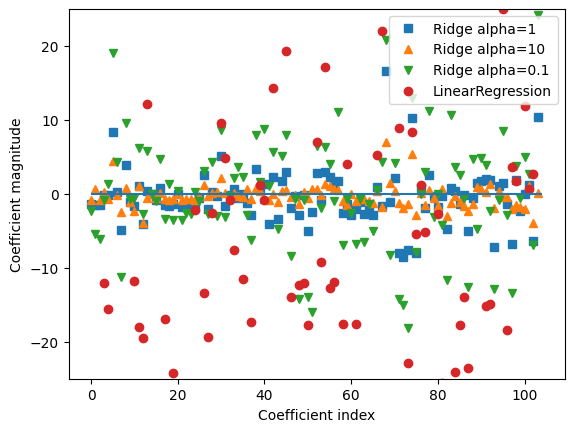

In [40]:
# 1. Pastikan semua model dilatih dulu
ridge = Ridge(alpha=1).fit(X_train, y_train) # Alpha default
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)

# 2. Baru deh bikin grafiknya
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

# 3. Bandingkan dengan Linear Regression biasa
plt.plot(lr.coef_, 'o', label="LinearRegression")

plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()
plt.show() # Tambahkan ini biar grafiknya muncul bersih tanpa teks sisa

## 2.8 Lasso Regression
Lasso (*Least Absolute Shrinkage and Selection Operator*) adalah jenis model linear lainnya yang menggunakan regularisasi untuk mencegah overfitting.

**Teori Singkat (Pendalaman):**
- **L1 Regularization**: Berbeda dengan Ridge yang menggunakan penalti kuadrat (L2), Lasso menggunakan penalti nilai absolut dari koefisien: $\alpha \sum |w_j|$.
- **Otomatis Seleksi Fitur**: Salah satu sifat paling penting dari Lasso adalah ia mampu memaksa koefisien fitur yang tidak penting menjadi **benar-benar nol**.
- **Kegunaan**: Sangat efektif digunakan jika kita memiliki ribuan fitur, namun kita menduga hanya sedikit fitur yang benar-benar berpengaruh terhadap hasil.

In [41]:
from sklearn.linear_model import Lasso
import numpy as np

# 1. Menjalankan Lasso dengan alpha default (1.0)
lasso = Lasso().fit(X_train, y_train)

print("--- Lasso dengan alpha=1.0 ---")
print(f"Training set score: {lasso.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso.score(X_test, y_test):.2f}")
print(f"Jumlah fitur yang digunakan: {np.sum(lasso.coef_ != 0)}")

--- Lasso dengan alpha=1.0 ---
Training set score: 0.29
Test set score: 0.21
Jumlah fitur yang digunakan: 4


## 2.9 Mengatur Alpha pada Lasso
Jika Lasso dengan `alpha=1.0` memberikan hasil yang buruk (skor rendah di training dan test), itu artinya model mengalami **Underfitting**. Kita perlu menurunkan nilai `alpha` agar model lebih fleksibel.

In [42]:
# Menurunkan alpha dan meningkatkan max_iter agar model punya waktu untuk belajar
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)

print("--- Lasso dengan alpha=0.01 ---")
print(f"Training set score: {lasso001.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso001.score(X_test, y_test):.2f}")
print(f"Jumlah fitur yang digunakan: {np.sum(lasso001.coef_ != 0)}")

--- Lasso dengan alpha=0.01 ---
Training set score: 0.90
Test set score: 0.77
Jumlah fitur yang digunakan: 33


## 2.10 Linear Models for Classification
Meskipun namanya mengandung kata "Regression", **Logistic Regression** sebenarnya adalah algoritma klasifikasi. Bersama dengan **Linear Support Vector Machines (Linear SVC)**, keduanya merupakan pondasi dasar untuk model klasifikasi linear.

**Konsep Utama:**
- Keduanya mencari garis (pada 2D) atau bidang (pada dimensi tinggi) yang paling baik dalam memisahkan kelas-kelas data.
- Keputusan dibuat berdasarkan apakah sebuah data berada di "sisi kanan" atau "sisi kiri" dari garis pemisah tersebut.

Text(0, 0.5, 'Feature 1')

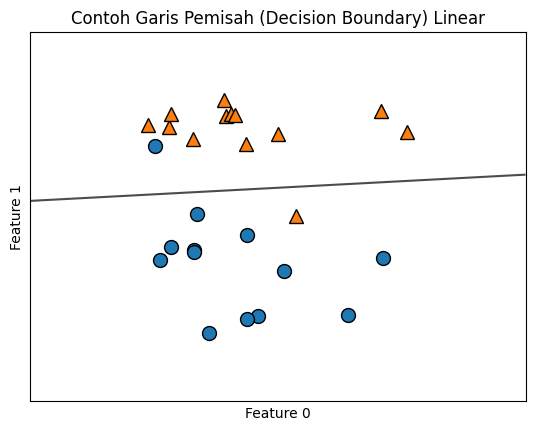

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import mglearn
import matplotlib.pyplot as plt

X, y = mglearn.datasets.make_forge()

# Visualisasi sederhana garis pemisah linear
mglearn.plots.plot_2d_separator(LinearSVC().fit(X, y), X, fill=False, alpha=.7)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.title("Contoh Garis Pemisah (Decision Boundary) Linear")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

## 2.11 Logistic Regression vs. Linear SVC
Walaupun tujuannya sama, yaitu klasifikasi, keduanya memiliki pendekatan matematis yang berbeda dalam menentukan garis pemisah.

**Perbedaan Singkat:**
- **Logistic Regression**: Menggunakan fungsi logistik untuk memprediksi probabilitas suatu kelas.
- **Linear SVC**: Berusaha memaksimalkan "jarak" (margin) antara garis pemisah dengan titik-titik data terdekat dari setiap kelas.
- Secara default, keduanya menggunakan **L2 Regularization**, sama seperti Ridge Regression.

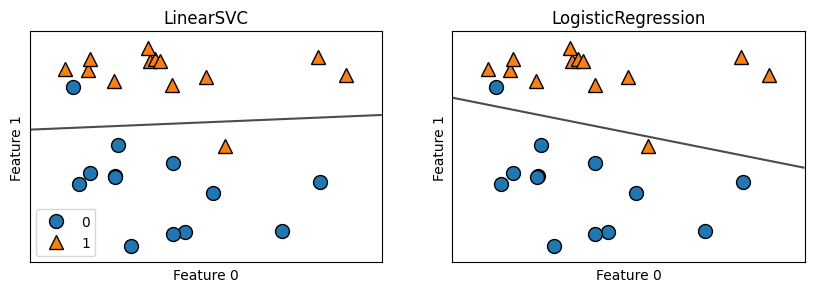

In [44]:
# Membandingkan kedua model secara berdampingan
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for model, ax in zip([LinearSVC(max_iter=10000), LogisticRegression()], axes):
    clf = model.fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=False, eps=0.5, ax=ax, alpha=.7)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title(clf.__class__.__name__)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

axes[0].legend()

## 2.12 Pengaruh Parameter C
Pada model klasifikasi linear, parameter **C** berfungsi sebagai pengatur regularisasi.

**Analisis Parameter:**
- **C Kecil (misal 0.01)**: Regularisasi kuat. Model mencoba menyesuaikan dengan mayoritas data dan mengabaikan beberapa titik data yang menyimpang (mencegah overfitting).
- **C Besar (misal 1000)**: Regularisasi lemah. Model berusaha sangat keras untuk mengklasifikasikan setiap titik data training dengan benar, yang bisa membuat garis pemisah menjadi sangat kompleks (berisiko overfitting).

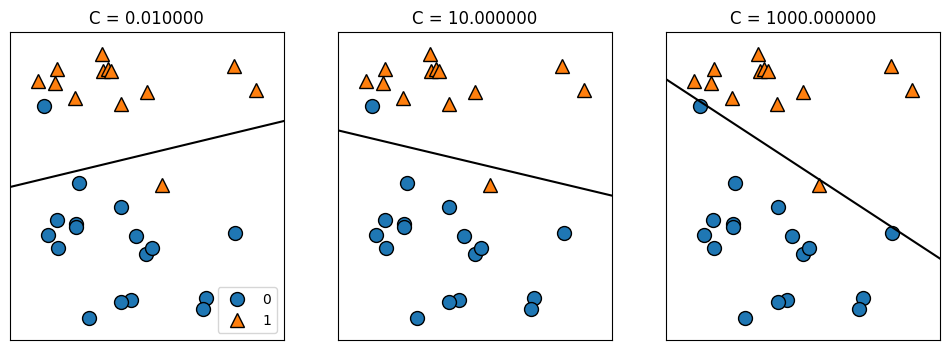

In [45]:
# Visualisasi efek parameter C pada LinearSVC
mglearn.plots.plot_linear_svc_regularization()

## 2.13 Linear Models for Multiclass Classification
Banyak model klasifikasi linear sebenarnya hanya dirancang untuk klasifikasi biner (dua kelas). Untuk menangani banyak kelas, teknik yang paling umum digunakan adalah **One-vs.-Rest (OvR)**.

**Cara Kerja OvR:**
- Sebuah model biner dibuat untuk setiap kelas yang ada.
- Setiap model mencoba membedakan satu kelas tertentu dari kelas-kelas lainnya.
- Saat prediksi, kelas yang memiliki skor tertinggi dari model binernya akan dipilih sebagai hasil akhir.

## 2.14 Implementasi Multiclass pada Dataset Blobs
Kita akan menerapkan `LinearSVC` pada dataset buatan bernama `blobs` yang memiliki tiga kelas berbeda untuk melihat bagaimana koefisien model bekerja pada kasus multiclass.

In [46]:
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC
import mglearn

# Menyiapkan dataset dengan 3 kelas
X, y = make_blobs(random_state=42)

# Melatih model LinearSVC
linear_svc = LinearSVC().fit(X, y)

print("Bentuk koefisien (Coefficients shape): ", linear_svc.coef_.shape)
print("Bentuk intercept (Intercept shape): ", linear_svc.intercept_.shape)

Bentuk koefisien (Coefficients shape):  (3, 2)
Bentuk intercept (Intercept shape):  (3,)


## 2.15 Visualisasi Keputusan Multiclass
Setelah model dilatih, kita bisa memvisualisasikan garis keputusan untuk masing-masing dari ketiga pengklasifikasi biner tersebut.

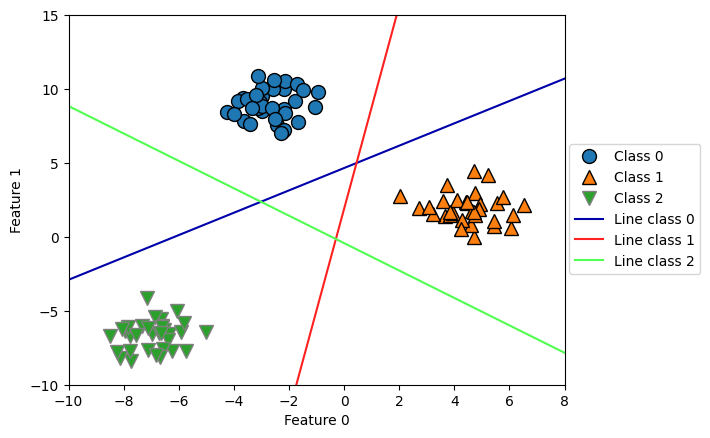

In [47]:
import matplotlib.pyplot as plt
import numpy as np

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
line = np.linspace(-15, 15)

for coef, intercept, color in zip(linear_svc.coef_, linear_svc.intercept_,
                                  mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)

plt.ylim(-10, 15)
plt.xlim(-10, 8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(['Class 0', 'Class 1', 'Class 2', 'Line class 0', 'Line class 1',
            'Line class 2'], loc=(1.01, 0.3))
plt.show()

## 2.16 Kelebihan dan Kekurangan Model Linear
**Kelebihan:**
- Sangat cepat untuk data besar.
- Cocok untuk data dengan fitur yang sangat banyak (sparse data).
- Mudah dipahami melalui nilai koefisien.

**Kekurangan:**
- Terbatas pada pola data yang linear (garis lurus).
- Performa bisa buruk pada data dengan fitur yang saling berinteraksi secara kompleks.

## 2.17 Naive Bayes Classifiers
Naive Bayes adalah kelompok pengklasifikasi yang sangat cepat dan sederhana. Mereka bekerja dengan menghitung probabilitas setiap fitur secara independen.

**Tipe Utama di scikit-learn:**
1. **GaussianNB**: Untuk data kontinu (seperti tinggi badan).
2. **BernoulliNB**: Untuk data biner (0 atau 1, seperti keberadaan kata dalam email).
3. **MultinomialNB**: Untuk data diskrit (seperti jumlah kemunculan kata).

In [48]:
from sklearn.naive_bayes import BernoulliNB
import numpy as np

# Contoh data biner sederhana
X = np.array([[0, 1, 0, 1],
              [1, 0, 1, 1],
              [0, 0, 0, 1],
              [1, 0, 1, 0]])
y = np.array([0, 1, 0, 1])

# Melatih model BernoulliNB
nb = BernoulliNB().fit(X, y)
print(f"Prediksi untuk data baru: {nb.predict([[1, 1, 0, 0]])}")

Prediksi untuk data baru: [0]


## 2.18 Decision Trees
Decision Trees adalah model yang mempelajari hierarki pertanyaan "jika/maka" yang berujung pada sebuah keputusan.

**Teori Singkat:**
- **Root Node**: Pertanyaan pertama yang membagi seluruh dataset.
- **Leaf Node**: Titik akhir di mana prediksi kategori atau nilai diberikan.
- **Mekanisme**: Model ini mencoba membagi data menjadi kelompok yang seseragam mungkin (*pure*) dengan memilih fitur yang paling informatif.

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

print(f"Accuracy on training set: {tree.score(X_train, y_train):.3f}")
print(f"Accuracy on test set: {tree.score(X_test, y_test):.3f}")

Accuracy on training set: 1.000
Accuracy on test set: 0.937


## 2.19 Mengontrol Kompleksitas Pohon (Pruning)
Tanpa batasan, Decision Trees cenderung terus membelah data sampai semua daun menjadi *pure*. Hal ini sering menyebabkan **Overfitting**.

**Teori Singkat:**
Ada dua cara umum untuk mencegah overfitting pada pohon:
1. **Pre-pruning**: Menghentikan pembuatan pohon lebih awal (misal: membatasi kedalaman maksimum).
2. **Post-pruning**: Membangun pohon sampai selesai, lalu membuang atau menggabungkan simpul yang memiliki informasi sedikit.

Di `scikit-learn`, kita fokus pada **Pre-pruning** menggunakan parameter seperti `max_depth`.

In [50]:
# Menerapkan pre-pruning dengan membatasi kedalaman pohon menjadi 4
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print(f"Accuracy on training set (depth=4): {tree.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (depth=4): {tree.score(X_test, y_test):.3f}")

Accuracy on training set (depth=4): 0.988
Accuracy on test set (depth=4): 0.951


## 2.20 Feature Importance
Salah satu keunggulan Decision Trees adalah kemampuannya untuk menunjukkan seberapa penting setiap fitur bagi model dalam mengambil keputusan.

**Keterangan:**
- Nilai berkisar antara 0 (tidak digunakan sama sekali) hingga 1 (sangat menentukan).
- Jumlah total dari semua nilai kepentingan fitur selalu sama dengan 1.

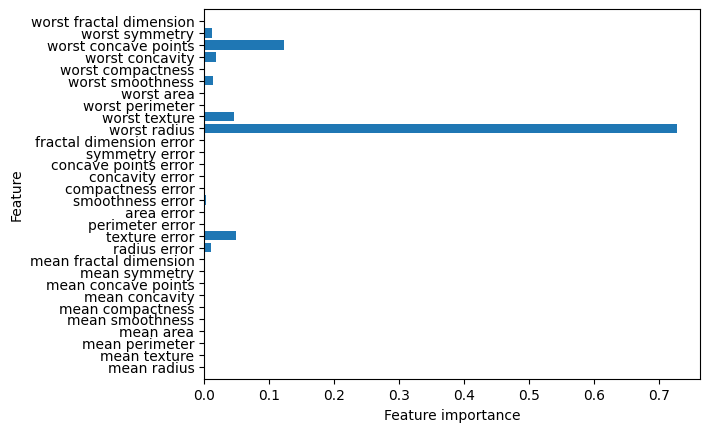

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(tree)

## 2.21 Ringkasan Decision Trees
**Kelebihan:**
- Mudah divisualisasikan dan dipahami oleh orang awam.
- Tidak memerlukan penskalaan data (scaling) seperti normalisasi.
- Bisa menangani fitur kategori maupun numerik secara bersamaan.

**Kekurangan:**
- Sangat mudah mengalami **Overfitting**, bahkan dengan pemangkasan (pruning).
- Cenderung memiliki stabilitas yang rendah (perubahan kecil pada data bisa mengubah struktur pohon secara drastis).

## 2.22 Ensembles of Decision Trees
Ensemble adalah metode yang menggabungkan beberapa model Machine Learning untuk menciptakan model yang lebih kuat. Dalam konteks pohon keputusan, ada dua jenis ensemble yang paling populer:
1. **Random Forests**
2. **Gradient Boosted Decision Trees (GBDT)**

## 2.23 Random Forests
Random Forest pada dasarnya adalah kumpulan dari banyak Decision Trees, di mana setiap pohon sedikit berbeda dari yang lain.

**Cara Kerja (Teori):**
- **Bootstrapping**: Mengambil sampel data secara acak untuk setiap pohon.
- **Random Feature Selection**: Saat membelah simpul, model hanya memilih dari subset fitur yang diacak.
- **Voting**: Prediksi akhir diambil berdasarkan suara terbanyak (klasifikasi) atau rata-rata (regresi) dari semua pohon.
- **Keuntungan**: Sangat kuat dalam mencegah **Overfitting** yang sering terjadi pada pohon tunggal.

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

# Membangun Random Forest dengan 100 pohon
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

print(f"Accuracy on training set: {forest.score(X_train, y_train):.3f}")
print(f"Accuracy on test set: {forest.score(X_test, y_test):.3f}")

Accuracy on training set: 1.000
Accuracy on test set: 0.958


## 2.24 Analisis Random Forest
Sama seperti pohon tunggal, Random Forest juga memberikan informasi tentang **Feature Importance**. Bedanya, hasil dari Random Forest biasanya lebih stabil dan mencakup lebih banyak fitur karena proses pengacakan yang dilakukan.

Text(0.5, 1.0, 'Feature Importance in Random Forest')

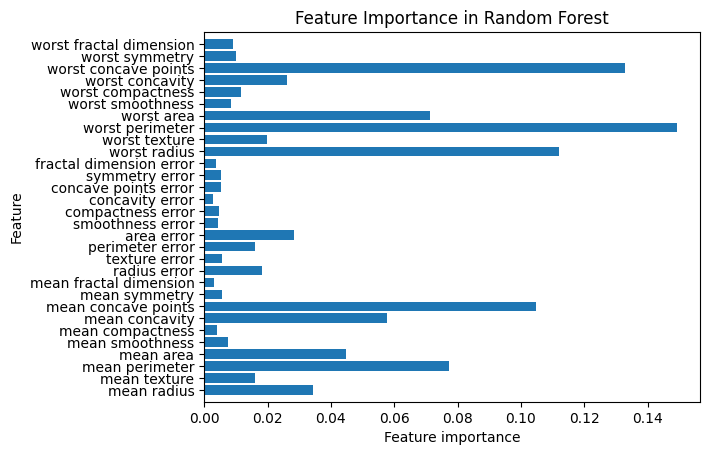

In [53]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(forest)
plt.title("Feature Importance in Random Forest")

## 2.25 Gradient Boosted Decision Trees (GBDT)
Berbeda dengan Random Forest yang membangun pohon secara mandiri, GBDT membangun pohon secara berurutan (*sequential*).

**Cara Kerja (Teori):**
- Setiap pohon baru mencoba memperbaiki kesalahan (error) yang dibuat oleh pohon sebelumnya.
- Menggunakan parameter **Learning Rate** untuk mengontrol seberapa kuat setiap pohon mencoba mengoreksi kesalahan sebelumnya.
- **Kekuatan**: Seringkali memberikan akurasi yang lebih tinggi daripada Random Forest jika parameternya diatur dengan tepat.
- **Kelemahan**: Lebih sensitif terhadap pengaturan parameter dan memerlukan waktu pelatihan yang lebih lama jika tidak hati-hati.

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

# GBDT dengan pengaturan default
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

print(f"Accuracy on training set (Default): {gbrt.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (Default): {gbrt.score(X_test, y_test):.3f}")

# Mencegah overfitting dengan membatasi kedalaman pohon
gbrt_pruned = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt_pruned.fit(X_train, y_train)

print(f"\nAccuracy on training set (depth=1): {gbrt_pruned.score(X_train, y_train):.3f}")
print(f"Accuracy on test set (depth=1): {gbrt_pruned.score(X_test, y_test):.3f}")

Accuracy on training set (Default): 1.000
Accuracy on test set (Default): 0.958

Accuracy on training set (depth=1): 0.988
Accuracy on test set (depth=1): 0.958


## 2.26 Ringkasan Model Ensemble
**Kelebihan:**
- Merupakan algoritma paling kuat untuk data tabular (data berbentuk tabel).
- Bekerja sangat baik tanpa memerlukan banyak prapemrosesan data (seperti scaling).

**Kekurangan:**
- Model "Black Box": Lebih sulit untuk divisualisasikan dan dipahami secara detail dibandingkan satu pohon tunggal.
- Memerlukan lebih banyak memori dan daya komputasi.

## 2.27 Kernelized Support Vector Machines
Kernelized SVM adalah pengembangan dari model linear yang memungkinkan pembuatan batas keputusan yang jauh lebih kompleks daripada sekadar garis lurus.

**Konsep Utama:**
- Model linear seringkali gagal pada data yang tidak bisa dipisahkan secara linear.
- SVM mengatasi ini dengan memetakan data ke dimensi yang lebih tinggi di mana data tersebut menjadi bisa dipisahkan secara linear.

## 2.28 Mengapa Kita Butuh Fitur Non-linear?
Terkadang, fitur asli tidak cukup untuk memisahkan data. Menambahkan fitur baru (misalnya kuadrat dari fitur yang ada) bisa membantu model linear melihat pola yang sebelumnya tersembunyi.

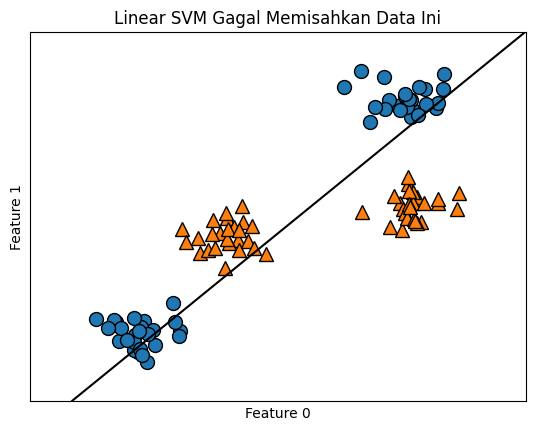

In [55]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

X, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

# Mencoba memisahkan dengan model linear biasa
linear_svm = LinearSVC(max_iter=10000).fit(X, y)
mglearn.plots.plot_2d_separator(linear_svm, X)
plt.title("Linear SVM Gagal Memisahkan Data Ini")
plt.show()

## 2.29 The Kernel Trick dan RBF Kernel
Menambah fitur secara manual itu melelahkan. SVM punya "Kernel Trick" yang memungkinkan kita menghitung hubungan data di dimensi tinggi tanpa harus benar-benar membuat fitur baru tersebut.

**RBF (Radial Basis Function) Kernel:**
Ini adalah kernel yang paling populer. Ia bekerja dengan mempertimbangkan jarak antar titik data. Prediksi dilakukan berdasarkan seberapa dekat sebuah data baru dengan titik-titik data penting yang disebut **Support Vectors**.

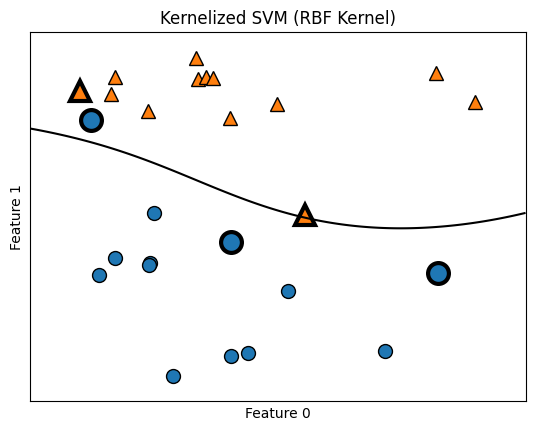

In [56]:
from sklearn.svm import SVC

X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)

mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

# Plot support vectors
sv = svm.support_vectors_
# Kelas dari support vectors diberikan oleh tanda dari dual_coef_
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Kernelized SVM (RBF Kernel)")
plt.show()

## 2.30 Memahami Parameter C dan Gamma
SVM memiliki dua "tombol" penting yang harus diatur:

1. **Gamma ($\gamma$)**: Mengontrol seberapa jauh pengaruh satu titik data tunggal.
   - **Gamma Kecil**: Pengaruhnya luas (garis batas sangat halus).
   - **Gamma Besar**: Pengaruhnya sempit (garis batas sangat berliku mengikuti titik data).
2. **C**: Parameter regularisasi (mirip dengan model linear).
   - **C Kecil**: Model sangat dibatasi (simpel).
   - **C Besar**: Model berusaha keras mengklasifikasikan setiap titik dengan benar (kompleks).

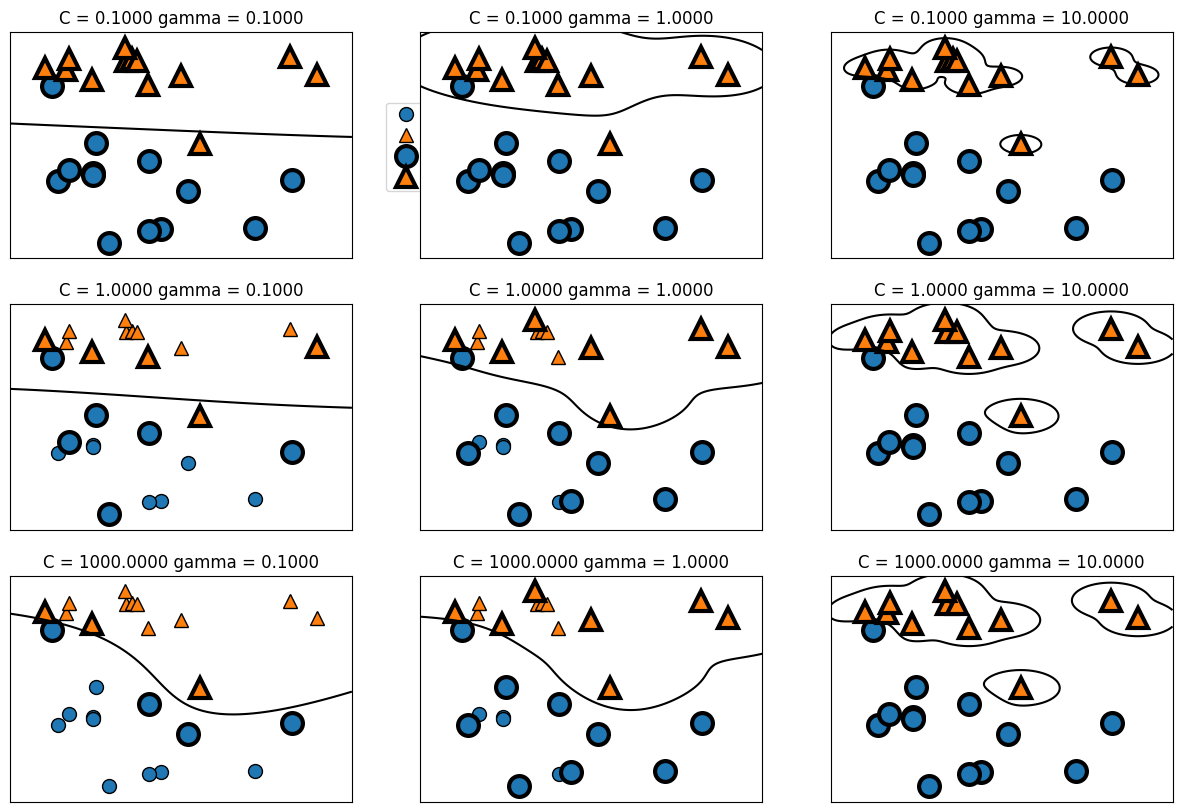

In [57]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
                  loc=(1.1, 0.3))

## 2.31 Ringkasan SVM
**Kelebihan:**
- Sangat kuat dan bekerja dengan baik pada berbagai dataset.
- Bisa membuat batas keputusan yang sangat kompleks.

**Kelemahan:**
- Sangat sensitif terhadap penskalaan data (data harus di-scale dulu ke rentang 0-1).
- Sulit dipahami/diinterpretasikan hasilnya dibandingkan model linear atau pohon.
- Lambat jika jumlah datanya sudah mencapai ratusan ribu atau jutaan.

## 2.32 Neural Networks (Multilayer Perceptrons)
Multilayer Perceptrons (MLP) adalah algoritma yang terinspirasi dari cara kerja otak manusia. MLP bekerja dengan memproses input melalui lapisan-lapisan "neuron" yang tersembunyi untuk menghasilkan prediksi.

**Konsep Utama:**
- **Input Layer**: Fitur-fitur awal dari data kita.
- **Hidden Layers**: Lapisan perantara di mana model mempelajari pola rumit.
- **Activation Function**: Fungsi (seperti ReLU atau tanh) yang menentukan apakah sebuah "neuron" harus aktif atau tidak.
- **Weights**: Bobot yang dipelajari model untuk menentukan pentingnya suatu koneksi antar neuron.

## 2.33 Implementasi MLPClassifier
Kita akan mencoba menggunakan `MLPClassifier` dari library `scikit-learn` pada dataset kanker payudara. Perlu diingat bahwa secara default, MLP menggunakan 100 hidden nodes, yang mungkin terlalu banyak untuk dataset kecil ini.

In [58]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

print(f"Accuracy on training set: {mlp.score(X_train, y_train):.2f}")
print(f"Accuracy on test set: {mlp.score(X_test, y_test):.2f}")

Accuracy on training set: 0.94
Accuracy on test set: 0.92


## 2.34 Pentingnya Penskalaan Data (Scaling)
Sama seperti SVM, Neural Networks sangat sensitif terhadap rentang nilai fitur. Jika satu fitur punya nilai 0-1 dan fitur lain punya nilai 0-1000, model akan kesulitan belajar.

**Solusi:**
Kita harus mengubah semua fitur agar memiliki rata-rata 0 dan varians 1 menggunakan `StandardScaler`.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print(f"Accuracy on training set (after scaling): {mlp.score(X_train_scaled, y_train):.3f}")
print(f"Accuracy on test set (after scaling): {mlp.score(X_test_scaled, y_test):.3f}")

Accuracy on training set (after scaling): 0.998
Accuracy on test set (after scaling): 0.965


## 2.35 Ringkasan Akhir Chapter 2
Setelah mempelajari berbagai algoritma Supervised Learning, berikut panduan singkat pemilihannya:

1. **Dataset Kecil/Simpel**: Gunakan **k-NN** atau **Linear Models**.
2. **Data Tabular/Tabel**: Gunakan **Random Forests** atau **Gradient Boosting** (paling populer).
3. **Data Sangat Besar/Kompleks (Citra, Suara)**: Gunakan **Neural Networks**.
4. **Data dengan Fitur Banyak**: Gunakan **Lasso** atau **Linear SVM**.